In [ ]:
import sys
%pip install --user plotly

import os
import glob
import subprocess

base = os.path.join(os.environ["APPDATA"], "Python")

candidates = glob.glob(
    os.path.join(base, "Python3*", "Scripts", "plotly_get_chrome.exe")
)

if candidates:
    subprocess.run([candidates[0]])
else:
    print("plotly_get_chrome.exe not found") 

import plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.dates as mdates



# path to files
# you need to change this path to where you saved the zip file from github

file_path_gps  = r"C:\Users\d85335mt\OneDrive - The University of Manchester\MGGA_exersice-main _v2\MGGA_exersice-main\2025-04-02\20250402-151647 - Test2.txt"
file_path_mgga = r"C:\Users\d85335mt\OneDrive - The University of Manchester\MGGA_exersice-main _v2\MGGA_exersice-main\2025-04-02\micro2025-04-02_f0000.txt"
# read files as pandas dataframes
gps_data  = pd.read_csv(file_path_gps)
mgga_data = pd.read_csv(file_path_mgga)


In [3]:
# Clean up column names (strip leading/trailing spaces)
mgga_data.columns = mgga_data.columns.str.strip()
# Strip spaces from string values in all columns
# This ensures no leading/trailing spaces remain in string-based columns
mgga_data = mgga_data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [4]:
# convert dates to pandas datetime objects 
gps_data['date time'] = pd.to_datetime(gps_data['date time'], format='%Y-%m-%d %H:%M:%S')
mgga_data['Time'] = pd.to_datetime(mgga_data['Time'], format="%d/%m/%Y %H:%M:%S.%f")

gps_data = gps_data.sort_values("date time")
mgga_data = mgga_data.sort_values("Time")

gps_data = gps_data.rename(columns={"date time": "timestamp"})
mgga_data = mgga_data.rename(columns={"Time": "timestamp"})

In [5]:
# Merge measurement data with the nearest GPS timestamp
merged_df = pd.merge_asof(mgga_data, gps_data, on="timestamp", direction="nearest")

# filter out negative CO2 and CH4 concentrations
merged_df = merged_df[merged_df['[CH4]_ppm']>0]
merged_df = merged_df[merged_df['[CO2]_ppm']>0]

In [6]:
### methane correction for interfearence with water vapor
## constants 
alpha    = -1.55636 
beta     = -12.25066 
a        = -0.00031  
b        = -0.00019   
C        = 0.01323  #(ppm)
G        = 0.99697 
sigma_nu = 0.00043 
sigma_G  = 0.00023 
sigma_C  = 0.00203  #(ppm)
sigma_L  = 0.00282  #(ppm)
sigma_n  = 0.00270  #(ppm)

In [7]:
# Corrects the methane concentration (CH4_wet_ppm) based on water vapor effects.
# Uses empirical correction factors (L18, L19, L20, L21, G, C) that have been determined through experimental calibration.
# The equation ensures that the methane concentration is adjusted for water vapor interference, which affects gas analyzers.
# Many methane sensors use infrared absorption spectroscopy to measure CH₄.
# Water vapor also absorbs infrared light at similar wavelengths as methane.
# This interference increases the detected methane concentration, making it appear higher than it actually is.

merged_df['[CH4]_ppm_corrected'] = (merged_df['[CH4]_ppm'] * G / (1 + (alpha * (( merged_df['[H2O]_ppm'] / 1000000) - (a + (b*merged_df['[CH4]_ppm'])))) + 
                                                        (beta*((merged_df['[H2O]_ppm'] /1000000)-(a+  (b*merged_df['[CH4]_ppm'])))* (( merged_df['[H2O]_ppm'] /1000000) - 
                                                                                                                            (a +  (b*merged_df['[CH4]_ppm'])))))) + C 
## methane uncertainty 
merged_df['[CH4]_ppm_uncertainty'] = np.sqrt((((merged_df['[CH4]_ppm']/(1 + (alpha *((merged_df['[H2O]_ppm']/1000000) - (a + (b*merged_df['[CH4]_ppm'])))) + 
                                                             (beta*((merged_df['[H2O]_ppm']/1000000) - (a + (b*merged_df['[CH4]_ppm'])))*((merged_df['[H2O]_ppm']/1000000) - 
                                                                (a + (b*merged_df['[CH4]_ppm']))))))**2)*(((sigma_nu*G)**2) + ((sigma_G*(1 + (alpha *((merged_df['[H2O]_ppm']/1000000) - 
                                                                (a + (b*merged_df['[CH4]_ppm'])))) + (beta*((merged_df['[H2O]_ppm']/1000000) - (a + (b*merged_df['[CH4]_ppm'])))*
                                                                ((merged_df['[H2O]_ppm']/1000000) - (a + (b*merged_df['[CH4]_ppm']))))))**2))) + (sigma_C**2) + (sigma_L**2) + (sigma_n**2))

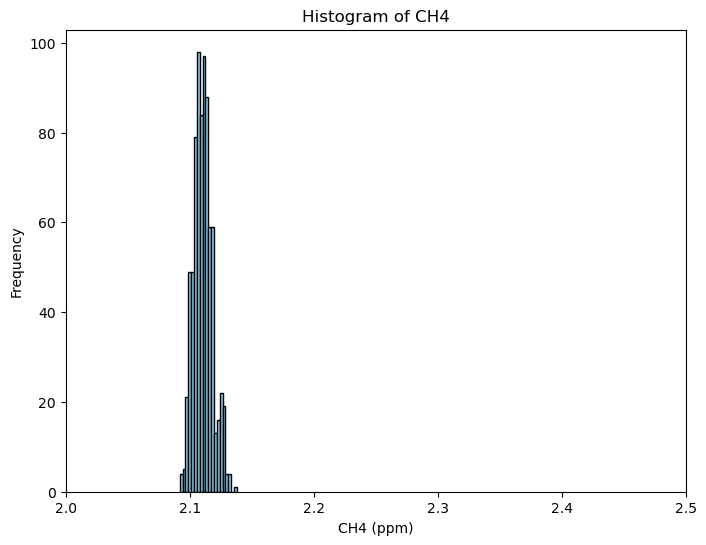

In [8]:

# plot histogram for CH4 
plt.figure(figsize=(8, 6))
plt.hist(merged_df['[CH4]_ppm_corrected'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of CH4')
plt.xlabel('CH4 (ppm)')
plt.ylabel('Frequency')
min_limit = 2
max_limit = 2.5
plt.xlim(min_limit, max_limit)
plt.show()

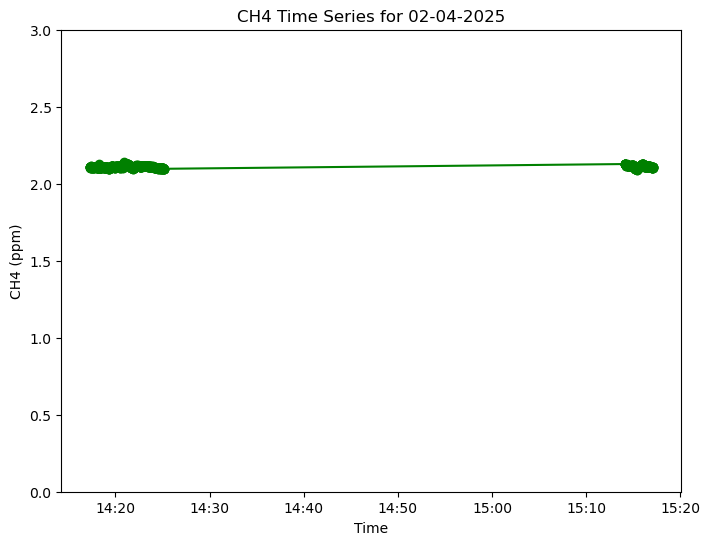

In [9]:

date_str = merged_df['timestamp'].iloc[0].strftime('%d-%m-%Y')  # Use the first timestamp in the dataset
# Plot Time Series for CO2
plt.figure(figsize=(8, 6))
plt.plot(merged_df['timestamp'], merged_df['[CH4]_ppm_corrected'], color='green', marker='o', linestyle='-')
# Set the title with the date
plt.title(f'CH4 Time Series for {date_str}')
plt.xlabel('Time')
plt.ylabel('CH4 (ppm)')

# Adjust y-axis limits
min_limit = 0
max_limit = 3
plt.ylim(min_limit, max_limit)

# Format x-axis to show only time (HH:MM:SS)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Show the plot
plt.show()

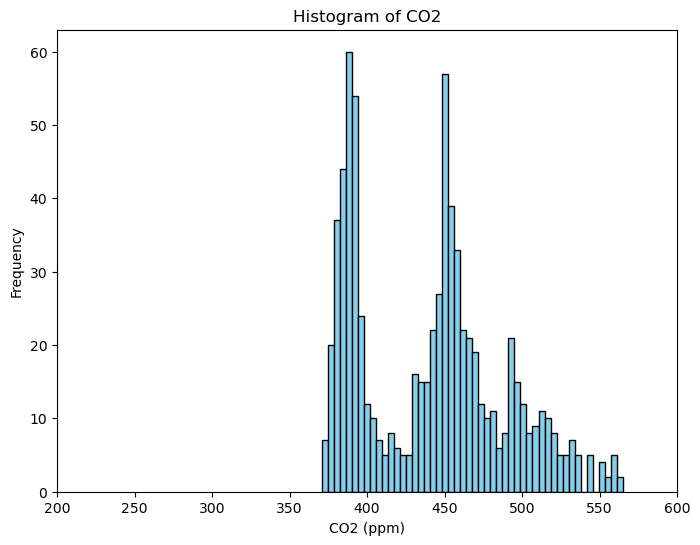

In [10]:
# Plot Histogram for CO2
plt.figure(figsize=(8, 6))
plt.hist(merged_df['[CO2]_ppm'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of CO2')
plt.xlabel('CO2 (ppm)')
plt.ylabel('Frequency')
min_limit = 200.
max_limit = 600. 
plt.xlim(min_limit, max_limit)
plt.show()

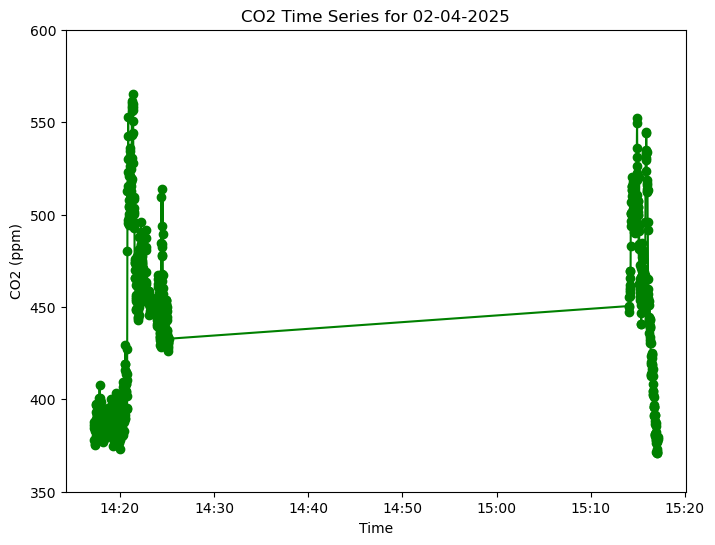

In [11]:
date_str = merged_df['timestamp'].iloc[0].strftime('%d-%m-%Y')  # Use the first timestamp in the dataset

# Plot Time Series for CO2
plt.figure(figsize=(8, 6))
plt.plot(merged_df['timestamp'], merged_df['[CO2]_ppm'], color='green', marker='o', linestyle='-')

# Set the title with the date
plt.title(f'CO2 Time Series for {date_str}')
plt.xlabel('Time')
plt.ylabel('CO2 (ppm)')

# Adjust y-axis limits
min_limit = 350
max_limit = 600
plt.ylim(min_limit, max_limit)

# Format x-axis to show only time (HH:MM:SS)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Show the plot
plt.show()

In [ ]:
# Create a Plotly figure with Mapbox tiles
fig = go.Figure(go.Scattermap(
    lat= merged_df['latitude'],  # Use the latitude values from your DataFrame
    lon= merged_df['longitude'],  # Use the longitude values from your DataFrame
    mode='markers',
    marker={'size': 12, 'color': merged_df['[CH4]_ppm_corrected'], 'colorscale': 'Viridis', 'colorbar': {'title': 'CH4 (ppm)'},
            'cmin': 0.,  # Set minimum value for color scale
        'cmax': 3.,  # Set maximum value for color scale
         },  # Color by CH4 values
    text= merged_df['[CH4]_ppm_corrected'],  # Display CH4 value on hover
))

# Set up Mapbox style and layout
fig.update_layout(
    mapbox_style="open-street-map",  # Use OpenStreetMap tiles for the base map
    mapbox_zoom=12,  # Zoom level
    mapbox_center={"lat": merged_df['latitude'].mean(), "lon": merged_df['longitude'].mean()},  # Center map on the average lat/lon
    title="CH4 concentration",
)
# Show the map
fig.show(renderer="browser")

end


In [ ]:
# Create a Plotly figure with Mapbox tiles
fig = go.Figure(go.Scattermap(
    lat= merged_df['latitude'],  # Use the latitude values from your DataFrame
    lon= merged_df['longitude'],  # Use the longitude values from your DataFrame
    mode='markers',
    marker={'size': 12, 'color': merged_df['[CO2]_ppm'], 'colorscale': 'Viridis', 'colorbar': {'title': 'CO2 (ppm)'},
        'cmin': 350.,  # Set minimum value for color scale
        'cmax': 450.,  # Set maximum value for color scale
         },
    text= merged_df['[CO2]_ppm'],  # Display CH4 value on hover
))

# Set up Mapbox style and layout
fig.update_layout(
    mapbox_style="open-street-map",  # Use OpenStreetMap tiles for the base map
    mapbox_zoom=12,  # Zoom level
    mapbox_center={"lat": merged_df['latitude'].mean(), "lon": merged_df['longitude'].mean()},  # Center map on the average lat/lon
    title="CO2 concentration",
)

# Show the map
fig.show(renderer="browser")

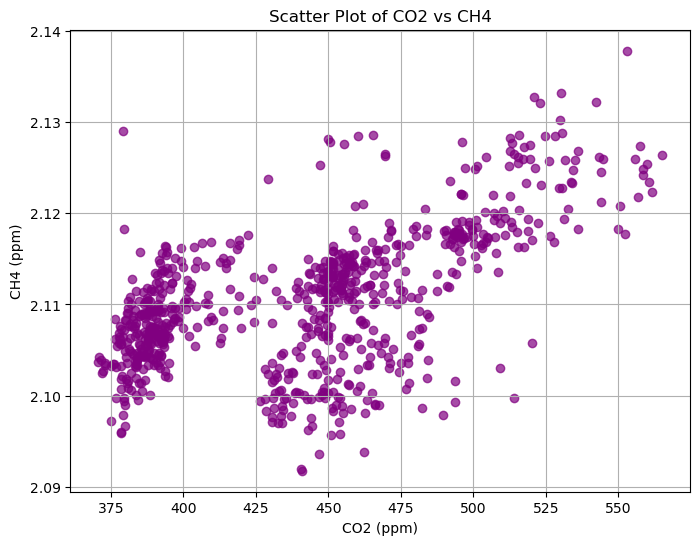

In [14]:
# Scatter plot of CO2 vs CH4
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['[CO2]_ppm'], merged_df['[CH4]_ppm_corrected'], color='purple', alpha=0.7)
plt.title('Scatter Plot of CO2 vs CH4')
plt.xlabel('CO2 (ppm)')
plt.ylabel('CH4 (ppm)')
plt.grid(True)
plt.show()
